In [37]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
import json
with open('../../data/corticalRegion2region.json', 'r') as f:
    detail2region = json.load(f)

clusters_table = pd.read_csv('../../data/ibl_cluster_tables.csv',
                             sep=',', index_col=0)

# Display the table
display(clusters_table)

,uuids,depths,channels,cluster_id,amp_max,amp_min,amp_median,amp_std_dB,contamination,contamination_alt,...,label,x,y,z,acronym,atlas_id,axial_um,lateral_um,pid,eid
0,918eb59c-2d17-4b4e-bbd2-7946d3604d2f,20.0,0,0,0.000520,0.000118,0.000186,2.231017,0.083911,0.072965,...,0.666667,-0.002289,-0.002537,-0.003595,TH,549,20.0,43.0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d
1,83a77b50-f409-4c3f-b992-782ebde32dbb,20.0,0,1,0.000369,0.000086,0.000162,1.829977,0.054216,0.043135,...,1.000000,-0.002289,-0.002537,-0.003595,TH,549,20.0,43.0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d
2,b4f7da58-9bf6-494e-a4cb-8d6934dcc928,20.0,0,2,0.000450,0.000143,0.000187,1.949605,0.436803,0.310567,...,0.333333,-0.002289,-0.002537,-0.003595,TH,549,20.0,43.0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d
3,8db87ffd-bea0-481e-91cb-8317b8da1563,20.0,0,3,0.000459,0.000162,0.000181,1.487011,0.141639,0.118156,...,1.000000,-0.002289,-0.002537,-0.003595,TH,549,20.0,43.0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d
4,3a2f08b3-0459-48ba-81fa-1d87a1086b62,20.0,0,4,0.000219,0.000130,0.000147,0.968083,0.000000,0.000000,...,0.666667,-0.002289,-0.002537,-0.003595,TH,549,20.0,43.0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295496,1df2371e-41e1-4bcc-a0b2-3dc1cb8d2d5b,700.0,69,725,0.000236,0.000125,0.000137,0.999767,0.000000,0.000000,...,0.333333,-0.001327,-0.000638,-0.003311,AV,255,700.0,11.0,79f44ba1-c931-4346-82eb-f628a9374045,c7bd79c9-c47e-4ea5-aea3-74dda991b48e
295497,dfa4b4d4-f181-4c85-947a-b150cb0eb2bd,2540.0,253,726,0.000195,0.000064,0.000109,1.786847,0.325005,0.242793,...,0.666667,-0.001903,-0.000650,-0.001372,SSp-ll6a,478,2540.0,11.0,79f44ba1-c931-4346-82eb-f628a9374045,c7bd79c9-c47e-4ea5-aea3-74dda991b48e
295498,7a440514-3206-4c9e-b0f9-7bde14fd6f0f,2560.0,255,727,0.000259,0.000078,0.000176,2.522561,0.000000,0.000000,...,0.666667,-0.001910,-0.000650,-0.001349,SSp-ll6a,478,2560.0,27.0,79f44ba1-c931-4346-82eb-f628a9374045,c7bd79c9-c47e-4ea5-aea3-74dda991b48e
295499,aa971667-5bb1-421a-8dcc-d53aa0797e09,2860.0,285,728,0.000279,0.000144,0.000155,0.866324,0.000000,0.000000,...,0.666667,-0.001995,-0.000616,-0.001020,SSp-ll5,1128,2860.0,11.0,79f44ba1-c931-4346-82eb-f628a9374045,c7bd79c9-c47e-4ea5-aea3-74dda991b48e


In [38]:
clusters_table.columns

Index(['uuids', 'depths', 'channels', 'cluster_id', 'amp_max', 'amp_min',
       'amp_median', 'amp_std_dB', 'contamination', 'contamination_alt',
       'drift', 'missed_spikes_est', 'noise_cutoff', 'presence_ratio',
       'presence_ratio_std', 'slidingRP_viol', 'spike_count', 'firing_rate',
       'label', 'x', 'y', 'z', 'acronym', 'atlas_id', 'axial_um', 'lateral_um',
       'pid', 'eid'],
      dtype='object')

In [39]:
#detail2region['fiber tracts'] = 'fiber tracts'

In [40]:
# import json
# with open('./corticalRegion2region.json', 'w') as f:
#     json.dump(detail2region, f)

In [41]:
# 4. Aggregate features across regions

# Restrict table to just good clusters
clusters_table = clusters_table[clusters_table['label'] == 1]

# Group the pandas table by region acronyms
# regions = clusters_table.groupby('acronym')

# Find the mean firing rate per region
# fr_region = regions.firing_rate.mean()

# Get out the values as arrays, the acronyms are stored in the index of the table
# and the mean firing rate as a column
# acronyms = fr_region.index.values
# fr = fr_region.values

In [42]:
#print(clusters_table.groupby('acronym').mean().columns)

In [43]:
clusters_table['acronym']

1              TH
3              TH
10             TH
13             TH
16             TH
           ...   
295293    SSp-ll4
295309    SSp-ll4
295469    SSp-ll5
295480    SSp-ll5
295486    SSp-ll4
Name: acronym, Length: 32766, dtype: object

In [44]:
clusters_table['region'] = clusters_table['acronym'].map(detail2region)

clusters_table

,uuids,depths,channels,cluster_id,amp_max,amp_min,amp_median,amp_std_dB,contamination,contamination_alt,...,x,y,z,acronym,atlas_id,axial_um,lateral_um,pid,eid,region
1,83a77b50-f409-4c3f-b992-782ebde32dbb,20.0,0,1,0.000369,0.000086,0.000162,1.829977,0.054216,0.043135,...,-0.002289,-0.002537,-0.003595,TH,549,20.0,43.0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d,NaN
3,8db87ffd-bea0-481e-91cb-8317b8da1563,20.0,0,3,0.000459,0.000162,0.000181,1.487011,0.141639,0.118156,...,-0.002289,-0.002537,-0.003595,TH,549,20.0,43.0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d,NaN
10,810521e9-4a3e-44f2-9d8a-9cf4b8a49b62,40.0,2,10,0.001130,0.000192,0.000378,2.381390,0.022846,0.023763,...,-0.002289,-0.002533,-0.003576,TH,549,40.0,59.0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d,NaN
13,3a47ef88-f22f-44fd-ad64-db402ce8f050,60.0,4,13,0.000560,0.000149,0.000274,1.220541,0.000000,0.000000,...,-0.002289,-0.002528,-0.003556,TH,549,60.0,43.0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d,NaN
16,58d694d7-dd0f-457a-b3a1-f9c40fa81f56,60.0,5,16,0.000403,0.000099,0.000193,1.327360,0.034921,0.031587,...,-0.002289,-0.002528,-0.003556,TH,549,60.0,11.0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295293,a5fd0987-34b8-428a-a42b-e6b61bdfafb1,2920.0,291,522,0.000338,0.000095,0.000185,1.201956,0.025077,0.025109,...,-0.002017,-0.000599,-0.000954,SSp-ll4,1094,2920.0,27.0,79f44ba1-c931-4346-82eb-f628a9374045,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,SSp-ll
295309,309dfd36-902b-421e-9088-510bdc8cc9f5,2980.0,296,538,0.000226,0.000061,0.000117,1.548661,0.242594,0.195657,...,-0.002037,-0.000597,-0.000887,SSp-ll4,1094,2980.0,43.0,79f44ba1-c931-4346-82eb-f628a9374045,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,SSp-ll
295469,28effa58-8568-4f66-a286-213c816425dd,2660.0,264,698,0.000239,0.000064,0.000125,1.722802,0.000000,0.000000,...,-0.001922,-0.000634,-0.001238,SSp-ll5,1128,2660.0,43.0,79f44ba1-c931-4346-82eb-f628a9374045,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,SSp-ll
295480,2f57a89b-e522-40fb-ad70-e04ceccc92ce,2860.0,284,709,0.000322,0.000133,0.000225,1.222507,0.000000,0.000000,...,-0.001995,-0.000616,-0.001020,SSp-ll5,1128,2860.0,43.0,79f44ba1-c931-4346-82eb-f628a9374045,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,SSp-ll


In [45]:
clusters_table = clusters_table[['region', 'amp_max', 'amp_min', 'amp_median',
                'amp_std_dB', 'presence_ratio', 'presence_ratio_std',
                'spike_count', 'firing_rate',]].copy()
clusters_table = clusters_table[~clusters_table['region'].isna()]
clusters_table

,region,amp_max,amp_min,amp_median,amp_std_dB,presence_ratio,presence_ratio_std,spike_count,firing_rate
31,MG,0.000371,0.000077,0.000147,1.683198,0.997872,39.848549,44315.0,9.451296
32,MG,0.000464,0.000131,0.000237,0.989352,0.991489,60.446754,45319.0,9.665424
34,MG,0.000342,0.000130,0.000215,1.010449,0.997872,14.012283,8536.0,1.820518
42,MG,0.000382,0.000131,0.000226,0.998021,0.987234,8.248402,6577.0,1.402712
43,MG,0.000373,0.000114,0.000196,1.160113,0.991489,45.298358,28217.0,6.017990
...,...,...,...,...,...,...,...,...,...
295293,SSp-ll,0.000338,0.000095,0.000185,1.201956,0.990164,115.683284,88328.0,14.514222
295309,SSp-ll,0.000226,0.000061,0.000117,1.548661,0.503279,33.771124,12700.0,2.086888
295469,SSp-ll,0.000239,0.000064,0.000125,1.722802,0.603279,14.819475,7421.0,1.219433
295480,SSp-ll,0.000322,0.000133,0.000225,1.222507,0.098361,7.903265,1367.0,0.224628


In [46]:
# 'amp_max', 'amp_min', 'amp_median',
#                 'amp_std_dB', 'presence_ratio', 'presence_ratio_std',

In [47]:
#clusters_table.to_csv('./Electrophysiology_region.csv', sep=',')


In [48]:
# ephs_df = clusters_table[['region', 
#                           'spike_count', 'firing_rate', 'amp_median']].groupby('region').mean() #

ephs_df = clusters_table[['region', 
                          'firing_rate', 'amp_median', 'amp_max', 'amp_min', 'amp_std_dB']].groupby('region').mean() #

ephs_df[ephs_df.columns] = ephs_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
ephs_df

,firing_rate,amp_median,amp_max,amp_min,amp_std_dB
region,,,,,
AAA,0.172228,-0.370504,-0.524868,-0.429146,-1.101386
ACAd,-0.585743,-0.539777,-0.551045,-0.523757,-0.425273
ACAv,-0.579460,-0.728002,-0.762916,-0.685871,-0.730990
ACB,-0.360593,-0.711113,-0.796520,-0.763657,-0.797867
ACVII,0.595760,1.110306,1.414095,0.906100,0.769018
...,...,...,...,...,...
XII,-0.180263,0.438343,1.122820,0.937448,0.056363
ZI,0.145310,0.053876,-0.083838,0.086349,-0.697279
fiber tracts,-0.168514,-0.027830,-0.153749,0.031135,-0.081374


In [49]:
region_sim = pd.read_csv('../../output/eucl_region_similarity_using174_region.csv', sep=',', index_col=0)

region_sim

,FRP,MOp,MOs,SSp-n,SSp-bfd,SSp-ll,SSp-m,SSp-ul,SSp-tr,SSp-un,...,SPIV,CENT,CUL,DEC,FOTU,SIM,AN,COPY,PFL,FL
FRP,1.000000,0.701205,0.746701,0.760539,0.791235,0.676851,0.739575,0.647752,0.746334,0.736902,...,0.134753,0.302799,0.154543,0.083386,0.052803,0.299386,0.093394,0.076032,0.118016,0.070755
MOp,0.701205,1.000000,0.874966,0.817356,0.795955,0.786861,0.918361,0.879372,0.637598,0.794357,...,0.106974,0.234783,0.134376,0.068398,0.048277,0.279184,0.077648,0.059424,0.129291,0.058719
MOs,0.746701,0.874966,1.000000,0.869013,0.884186,0.851463,0.915525,0.837040,0.713349,0.894804,...,0.116122,0.257584,0.142511,0.072146,0.050072,0.291861,0.082741,0.064222,0.117162,0.062239
SSp-n,0.760539,0.817356,0.869013,1.000000,0.900155,0.802306,0.873557,0.792269,0.751525,0.865196,...,0.120854,0.265055,0.146522,0.072817,0.050975,0.305422,0.085317,0.066640,0.113474,0.066466
SSp-bfd,0.791235,0.795955,0.884186,0.900155,1.000000,0.810548,0.852457,0.770874,0.775751,0.895481,...,0.126289,0.283654,0.154039,0.078130,0.052340,0.309706,0.089718,0.068243,0.112104,0.066529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SIM,0.299386,0.279184,0.291861,0.305422,0.309706,0.311342,0.293598,0.291249,0.330487,0.299581,...,0.097678,0.220708,0.217350,0.084030,0.094220,1.000000,0.099072,0.041921,0.083254,0.057002
AN,0.093394,0.077648,0.082741,0.085317,0.089718,0.079552,0.080415,0.076875,0.094590,0.083111,...,0.318483,0.240166,0.141139,0.079462,0.079608,0.099072,1.000000,0.043231,0.034422,0.063730
COPY,0.076032,0.059424,0.064222,0.066640,0.068243,0.060793,0.061972,0.054752,0.075859,0.066175,...,0.124652,0.100852,0.043797,0.029805,0.021443,0.041921,0.043231,1.000000,0.020892,0.174615
PFL,0.118016,0.129291,0.117162,0.113474,0.112104,0.108920,0.123260,0.122335,0.093388,0.105935,...,0.036082,0.060628,0.048743,0.027647,0.035144,0.083254,0.034422,0.020892,1.000000,0.025671


In [50]:
shared_region = list(set(ephs_df.index).intersection(region_sim.index))
print(len(shared_region))

163


1.9731916939750487 1.6692395289922584 6.877420525450526


,PARN,MD,AUDd,POST,ORBl,MS,SCs,ORBvl,LSr,VPL,...,AAA,DEC,AON,PL,PRE,FS,VII,MDRNv,CEA,COAp
PARN,1.000000,0.374693,0.166130,0.349010,0.203751,0.367953,0.240827,0.200724,0.177124,0.535173,...,0.202373,0.437613,0.191033,0.221943,0.232621,0.151873,0.687900,0.232612,0.184762,0.165392
MD,0.374693,1.000000,0.318752,0.633427,0.519900,0.282121,0.568835,0.528643,0.438736,0.550160,...,0.496027,0.496287,0.481388,0.552890,0.533911,0.368862,0.332901,0.097012,0.449299,0.395563
AUDd,0.166130,0.318752,1.000000,0.454489,0.458422,0.235954,0.521645,0.363316,0.520515,0.183878,...,0.333853,0.360767,0.484706,0.474407,0.558080,0.455040,0.145051,0.043904,0.531812,0.583253
POST,0.349010,0.633427,0.454489,1.000000,0.522676,0.338454,0.652141,0.460203,0.478624,0.394469,...,0.416576,0.646812,0.502557,0.576410,0.627325,0.383784,0.293819,0.090132,0.505813,0.462538
ORBl,0.203751,0.519900,0.458422,0.522676,1.000000,0.200965,0.786184,0.792008,0.822452,0.290214,...,0.623422,0.360754,0.915536,0.899816,0.737289,0.630877,0.179439,0.052855,0.817747,0.719799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FS,0.151873,0.368862,0.455040,0.383784,0.630877,0.185778,0.566869,0.565011,0.697550,0.213177,...,0.618552,0.290805,0.669009,0.593315,0.608111,1.000000,0.140757,0.036968,0.627891,0.661507
VII,0.687900,0.332901,0.145051,0.293819,0.179439,0.378719,0.209312,0.178174,0.156503,0.499223,...,0.192505,0.367575,0.168565,0.193177,0.207119,0.140757,1.000000,0.212018,0.159647,0.144417
MDRNv,0.232612,0.097012,0.043904,0.090132,0.052855,0.105203,0.061575,0.053516,0.045485,0.153896,...,0.050061,0.109875,0.049256,0.057560,0.057886,0.036968,0.212018,1.000000,0.048435,0.042825
CEA,0.184762,0.449299,0.531812,0.505813,0.817747,0.194014,0.759747,0.663021,0.886460,0.249217,...,0.529192,0.349845,0.866377,0.806847,0.726093,0.627891,0.159647,0.048435,1.000000,0.852640


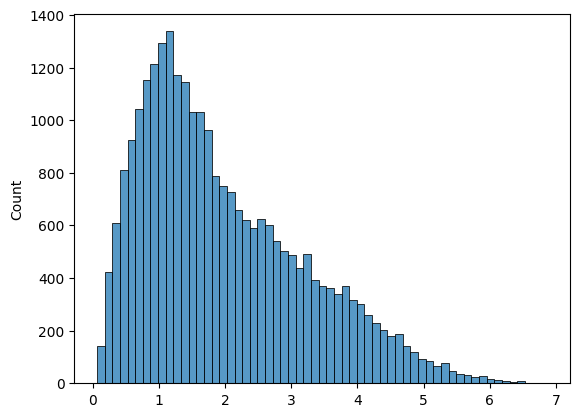

In [51]:
eucl_df = pd.DataFrame(np.zeros((len(shared_region), len(shared_region))), 
                       index = (shared_region), columns=(shared_region)
                      )

for i in shared_region:
    for j in shared_region:
        eucl_df.loc[i,j] = np.linalg.norm(ephs_df.loc[i] - ephs_df.loc[j])

v = eucl_df.values.reshape(-1)
v = v[v>0]
print(np.mean(v), np.median(v), np.max(v))

alpha = np.median(v)

sns.histplot(v)

ephs_sim = np.e**(-eucl_df/alpha)
ephs_sim

In [52]:
ephs_sim.to_csv('../../output/ephs_sim_regions.csv', sep=',')

In [17]:
region_sim2 = region_sim.loc[shared_region, shared_region].copy()
ephs_sim2 = ephs_sim.loc[shared_region, shared_region].copy()

In [18]:
cmp_df = pd.DataFrame()
for i in range(0, len(region_sim2)):
    for j in range(0, len(region_sim2)):
        if i < j:
            continue
        cmp_df = pd.concat([cmp_df,
                            pd.DataFrame({'region1': [region_sim2.columns[i]],
                                          'region2': [region_sim2.columns[j]],
                                          'ephs_sim': [ephs_sim.iloc[i,j]],
                                          'region_sim': [region_sim2.iloc[i,j]],
                                         })
                           ], axis=0)

cmp_df

,region1,region2,ephs_sim,region_sim
0,PARN,PARN,1.000000,1.000000
0,MD,PARN,0.374693,0.117965
0,MD,MD,1.000000,1.000000
0,AUDd,PARN,0.166130,0.210061
0,AUDd,MD,0.318752,0.507124
...,...,...,...,...
0,COAp,FS,0.661507,0.729272
0,COAp,VII,0.144417,0.226922
0,COAp,MDRNv,0.042825,0.137896
0,COAp,CEA,0.852640,0.686333


In [19]:
cmp_df2 = cmp_df[cmp_df['region1'] != cmp_df['region2']].copy()
# cmp_df2['syn_sim'] = np.square((cmp_df2['syn_sim'] - np.min(cmp_df2['syn_sim'])) / (
#     np.max(cmp_df2['syn_sim']) - np.min(cmp_df2['syn_sim'])))
cmp_df2

,region1,region2,ephs_sim,region_sim
0,MD,PARN,0.374693,0.117965
0,AUDd,PARN,0.166130,0.210061
0,AUDd,MD,0.318752,0.507124
0,POST,PARN,0.349010,0.633208
0,POST,MD,0.633427,0.149211
...,...,...,...,...
0,COAp,PRE,0.689839,0.478348
0,COAp,FS,0.661507,0.729272
0,COAp,VII,0.144417,0.226922
0,COAp,MDRNv,0.042825,0.137896


In [20]:
th = 0.01
if len(cmp_df2[cmp_df2['ephs_sim']<th].copy()) / len(cmp_df2.copy()) > 0.1:
    print(True)
    cmp_df2 = cmp_df2[(cmp_df2['ephs_sim']>th)&(cmp_df2['ephs_sim']<1)].copy()
else:
    print(False)

if len(cmp_df2[cmp_df2['region_sim']<th].copy()) / len(cmp_df2.copy()) > 0.1:
    print(True)
    cmp_df2 = cmp_df2[(cmp_df2['region_sim']>th)&(cmp_df2['region_sim']<1)].copy()
else:
    print(False)

False
False


In [21]:
cmp_df3 = cmp_df2.copy() #.sample(500)
# cmp_df3['ephs_sim_norm'] = np.sqrt(cmp_df3['ephs_sim'])
cmp_df3['ephs_sim_norm'] = cmp_df3['ephs_sim']
cmp_df3

,region1,region2,ephs_sim,region_sim,ephs_sim_norm
0,MD,PARN,0.374693,0.117965,0.374693
0,AUDd,PARN,0.166130,0.210061,0.166130
0,AUDd,MD,0.318752,0.507124,0.318752
0,POST,PARN,0.349010,0.633208,0.349010
0,POST,MD,0.633427,0.149211,0.633427
...,...,...,...,...,...
0,COAp,PRE,0.689839,0.478348,0.689839
0,COAp,FS,0.661507,0.729272,0.661507
0,COAp,VII,0.144417,0.226922,0.144417
0,COAp,MDRNv,0.042825,0.137896,0.042825


<Axes: xlabel='ephs_sim_norm', ylabel='Count'>

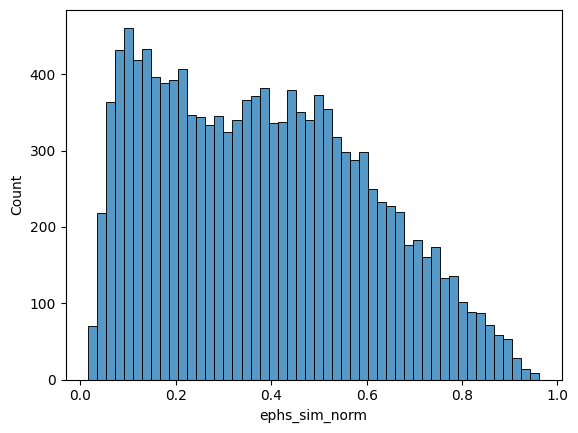

In [22]:
sns.histplot(cmp_df3, bins=50, x='ephs_sim_norm')

<Axes: xlabel='region_sim', ylabel='Count'>

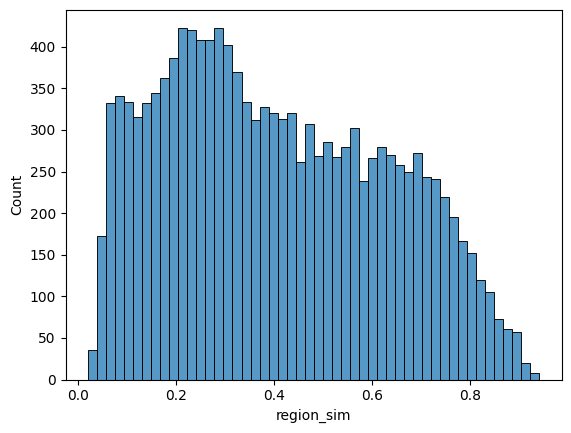

In [23]:
sns.histplot(cmp_df3, bins=50, x='region_sim')

In [24]:
cmp_df3['ephs_sim_cat'] = -1
n_bin = 50
for i in list(range(1,n_bin+1))[::-1]:
    cmp_df3.loc[cmp_df3['ephs_sim_norm']<=i/n_bin, 'ephs_sim_cat'] = i

cmp_df3['region_sim_cat'] = -1
for i in list(range(1,n_bin+1))[::-1]:
    cmp_df3.loc[cmp_df3['region_sim']<=i/n_bin, 'region_sim_cat'] = i

# cmp_df3 = cmp_df3[gene_sim['euc_dis_cat'] != -1].copy()
cmp_df3

,region1,region2,ephs_sim,region_sim,ephs_sim_norm,ephs_sim_cat,region_sim_cat
0,MD,PARN,0.374693,0.117965,0.374693,19,6
0,AUDd,PARN,0.166130,0.210061,0.166130,9,11
0,AUDd,MD,0.318752,0.507124,0.318752,16,26
0,POST,PARN,0.349010,0.633208,0.349010,18,32
0,POST,MD,0.633427,0.149211,0.633427,32,8
...,...,...,...,...,...,...,...
0,COAp,PRE,0.689839,0.478348,0.689839,35,24
0,COAp,FS,0.661507,0.729272,0.661507,34,37
0,COAp,VII,0.144417,0.226922,0.144417,8,12
0,COAp,MDRNv,0.042825,0.137896,0.042825,3,7


In [25]:
cross_df = pd.crosstab(cmp_df3['ephs_sim_cat'], cmp_df3['region_sim_cat'])

cross_df2 = pd.DataFrame(np.zeros((n_bin, n_bin)),
                         index=range(1, n_bin+1),
                         columns=range(1, n_bin+1)
                        )
cross_df2.index.name = 'ephs_sim_cat'
cross_df2.columns.name = 'region_sim_cat'

for i in cross_df.index:
    for j in cross_df.columns:
        cross_df2.loc[i, j] = cross_df.loc[i, j]

# cross_df = cross_df.iloc[::-1,]
cross_df2

region_sim_cat,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
ephs_sim_cat,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,2.0,2.0,1.0,9.0,11.0,16.0,10.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,16.0,16.0,11.0,16.0,28.0,20.0,15.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,39.0,37.0,6.0,12.0,11.0,14.0,18.0,21.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,1.0,18.0,42.0,14.0,9.0,16.0,13.0,33.0,35.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,2.0,11.0,27.0,17.0,9.0,6.0,19.0,26.0,21.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,3.0,11.0,37.0,16.0,15.0,5.0,13.0,21.0,22.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,5.0,6.0,20.0,17.0,7.0,11.0,16.0,20.0,23.0,...,4.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,1.0,11.0,22.0,10.0,10.0,12.0,16.0,16.0,17.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
import numpy as np
import pandas as pd

masked = np.ma.masked_equal(cross_df2.values, 0)

median = np.ma.median(masked)
mad = np.ma.median(np.abs(masked - median))
robust_z = 0.6745 * (masked - median) / mad

thresh = 3.5
mask_np = np.abs(robust_z.filled(np.nan)) > thresh
mask_df = pd.DataFrame(mask_np,
                      index=cross_df2.index,
                      columns=cross_df2.columns)

idx_pairs = mask_df.stack()[mask_df.stack()].index.tolist()

print(len(idx_pairs))

from scipy.ndimage import uniform_filter

mean_8nb = uniform_filter(cross_df2, size=3, mode='mirror') * 9/8 - cross_df2/8

cross_df2[mask_df] = mean_8nb[mask_df]

21


In [27]:
extreme_value = np.where(cross_df2.values == cross_df2.values.max())
cross_df2.values.max()

np.float64(28.5)

In [28]:
# extreme_value

In [29]:
# top=5
# top3_flat_idx = np.argpartition(cross_df2.values.ravel(), -top)[-top:]
# np.unravel_index(top3_flat_idx, cross_df2.shape)

In [30]:
# top3_flat_idx = np.argpartition(cross_df2.values.ravel(), -3)[-3:]
# extreme_value = np.unravel_index(top3_flat_idx, cross_df2.shape)

# xs, ys = extreme_value[0], extreme_value[1]
# median = np.median(cross_df2.values)

# for x, y in zip(xs, ys):
#     bin=(x, y)
#     print(bin)
#     cross_df2.iloc[bin] = median

# cross_df2

In [31]:
x = cmp_df3['region_sim_cat']
y = n_bin-cmp_df3['ephs_sim_cat']

def linear_function(x, a, b):
    return a * x + b
    
params, covariance = curve_fit(linear_function, x, y)
a, b = params
x_fit = np.linspace(min(x-1), max(x+1), 100)
y_fit = linear_function(x_fit, a, b)
a

np.float64(-0.44345784494721646)

In [32]:
np.mean(cross_df2.iloc[::-1, ].values)

np.float64(5.1977)

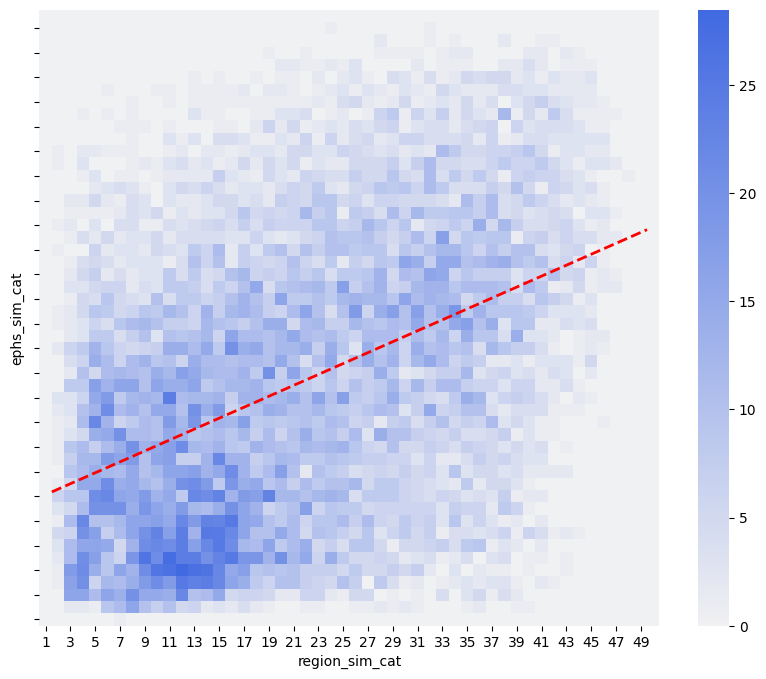

In [33]:
f, ax = plt.subplots(1,1,figsize=(10,8))

sns.heatmap(cross_df2.iloc[::-1, ], 
            cmap=sns.color_palette("light:royalblue", as_cmap=True),
            # mask=cross_df<=0
           )

tick_pos = np.arange(0, n_bin, 2)
plt.xticks(tick_pos+0.5, rotation=0)
plt.yticks(tick_pos+1.5, rotation=0)

plt.plot(x_fit, y_fit, color='red', 
         linewidth=2, linestyle='--',
         label='Fitted Curve')

plt.xlabel("Similarity of PPSS patterns")
plt.ylabel("Electrophysiology similarity")

#plt.savefig('./cmp_ephs_sim.png', dpi=400, bbox_inches='tight')
plt.savefig('./ephy_ppss.svg', bbox_inches='tight')
plt.show()

In [35]:
cmp_df4 = cmp_df3.copy() #[(cmp_df3['region_sim']>=0.16)&(cmp_df3['region_sim']<=1)].copy()
# th=0.15
# cmp_df4 = cmp_df3[(cmp_df3['ephs_sim']>=th)&(cmp_df3['region_sim']>=th)].copy()
stats.pearsonr(cmp_df4['ephs_sim_norm'], 
               cmp_df4['region_sim'])

PearsonRResult(statistic=np.float64(0.4513872936602234), pvalue=np.float64(0.0))

In [36]:
stats.pearsonr(cmp_df4['ephs_sim_cat'], 
               cmp_df4['region_sim_cat'])

PearsonRResult(statistic=np.float64(0.4512809601853441), pvalue=np.float64(0.0))